In [1]:
# import package

import numpy as np
import os
import netCDF4 as nc
import linecache as lc
import pandas as pd
import time
from scipy import io as sio
import progressbar
import datetime as dt
import aacgmv2
from apexpy import Apex
import ipdb
import numpy.linalg as LA

from pyitlib import discrete_random_variable as drv
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score

<xarray.Dataset>
Dimensions:   (products: 52, time1: 96409)
Coordinates:
  * products  (products) <U33 'Bartels Rotation Number' ... 'Magnetosonic Mach No.'
  * time1     (time1) datetime64[ns] 2007-01-01 ... 2017-12-31
Data variables:
    all1      (time1, products) float64 2.366e+03 51.0 51.0 ... -5.0 39.0 6.0
Attributes:
    mission:  omni
<xarray.DataArray 'all1' (time1: 96409, products: 52)>
array([[ 2.366e+03,  5.100e+01,  5.100e+01, ..., -2.200e+01,  1.500e+01,
         6.300e+00],
       [ 2.366e+03,  5.100e+01,  5.100e+01, ..., -3.000e+00,  1.500e+01,
         6.600e+00],
       [ 2.366e+03,  5.100e+01,  5.100e+01, ..., -2.000e+00,  2.200e+01,
         6.300e+00],
       ...,
       [ 2.515e+03,  5.100e+01,  5.200e+01, ..., -8.800e+01,  4.200e+01,
         5.700e+00],
       [ 2.515e+03,  5.100e+01,  5.200e+01, ..., -4.200e+01,  3.600e+01,
         6.000e+00],
       [ 2.515e+03,  5.100e+01,  5.200e+01, ..., -5.000e+00,  3.900e+01,
         6.000e+00]])
Coordinates:
  * produc

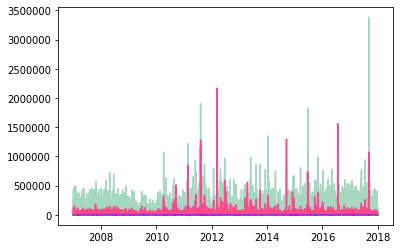

In [2]:
############## omni data read #####################

from datetime import datetime
from aidapy import load_data
import aidapy.aidaxr


# Set the start and end date as year, month, day
t0 = datetime(2007, 1, 1)
t1 = datetime(2017, 12, 31)

# Download the data
import aidapy.aidaxr

xr_omni = load_data(mission='omni', start_time=t0, end_time=t1)
print(xr_omni)
print(xr_omni['all1'])
xr_omni['all1'].graphical.peek()
#ts = load_data(mission='omni', start_time=t0, end_time=t1)

'''
for var in xr_omni['all1'].products.values:
    print("{:35} (unit: {})".format(var, xr_omni['all1'].attrs[var]))
'''
# Convert the time series data to pandas format
data_pd = xr_omni['all1'].to_pandas()
#ts.data['all1'].timeseries.values

In [5]:
d = dt.datetime(2015,6,29,8)
d1 = dt.datetime(2015,6,29,11)
print(d)
d2 = dt.datetime(2015,6,29,8)+dt.timedelta(hours=3)

print(d<d2)
print(data_pd.keys())

2015-06-29 08:00:00
True
Index(['Bartels Rotation Number', 'ID IMF Spacecraft',
       'ID SW Plasma Spacecraft', 'points(IMF Average)',
       'points(Plasma Average)', '|B|', 'Magnitude of Avg Field Vector',
       'Lat. Angle of Aver. Field Vector', 'Long. Angle of Aver. Field Vector',
       'Bx GSE, GSM', 'By GSE', 'Bz GSE', 'By GSM', 'Bz GSM', 'sigma |B|',
       'sigma B', 'sigma Bx', 'sigma By', 'sigma Bz', 'Proton Temperature',
       'Proton Density', 'Plasma Flow Speed', 'Plasma Flow Long. Angle',
       'Plasma Flow Lat. Angle', 'Na/Np', 'Flow Pressure', 'sigma T',
       'sigma N', 'sigma V', 'sigma phi V', 'sigma theta V', 'sigma Na/Np',
       'Electric Field', 'Plasma Beta', 'Alfven Mach Number', 'Kp', 'R',
       'DST Index', 'AE Index', 'Proton Flux > 1MeV', 'Proton Flux > 2MeV',
       'Proton Flux > 4MeV', 'Proton Flux > 10MeV', 'Proton Flux > 30MeV',
       'Proton Flux > 60MeV', 'flag', 'ap index', 'f10.7 index', 'PC(N) index',
       'AL index (Kyoto)', 'AU index

In [4]:
############## read omni date #####################

from multiprocessing import Pool
from multiprocessing import Process

features = ['DST Index',
            'AE Index',
            'ap index',
            'f10.7 index',
            'Kp',
            'Plasma Flow Speed',
            'Bx GSE, GSM',
            'By GSM',
            'Bz GSM']
#ts.data['time1'][1]


  

In [5]:
# global value
def init():
    global data
    data = xr_omni['time1']


    
def omni_read(ind):
    #global data 
    d_out = np.zeros(4,)
    time_index = data[ind]
    t = (time_index - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')
    a = datetime.utcfromtimestamp(t)
    
    d_out[0] = int(int(a.year))
    d_out[1] = int(int(a.month))
    d_out[2] = int(int(a.day))
    d_out[3] = int(int(a.hour))
    #ipdb.set_trace()
    #print(type(d_out[0]))
    #print(type(d_out[1]))
    #print(type(d_out[2]))
    #print(type(d_out[3]))
    Omni_time = dt.datetime(int(d_out[0]),int(d_out[1])\
                            ,int(d_out[2]),int(d_out[3]))

    return Omni_time
    #return a.year, a.month, a.day, a.hour

if __name__ == '__main__':
    
    #global data  
    
    data = xr_omni['time1']
    start = time.time()
    pool = Pool(8,init,())
    #pool=Pool(8)
    
    index =  range(1,xr_omni['time1'].size)    
    print(index)
        
    date = pool.map(omni_read, index)
    print(date[1000])
    
    end = time.time()
    print('running time: ', end-start)    


/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:12: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  if sys.path[0] == '':
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:12: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  if sys.path[0] == '':
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:12: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  if sys.path[0] == '':
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:12: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  if sys.path[0] == '':
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ip

range(1, 96409)
2007-02-11 17:00:00
running time:  17.238190412521362


In [6]:
print(len(date))
print(date[1])
#print(Omni_time.shape)

96408
2007-01-01 02:00:00


In [7]:
string = lc.getlines("cosmic_list.txt")
print(string[0])
len(string)

/export/scratch2/andong/Data/ROdata/cosmic2013/ionPrf/2010.182/ionPrf_C003.2010.182.17.13.G20_2013.3520.nc



3378981

In [8]:
## CPU multiprocessing

#from multiprocessing import Pool, cpu_count
#from functools import partial

from scipy import io as sio
from multiprocessing import cpu_count, Pool
from random import sample
import tqdm
import ipdb
# global value
def init():
    global string
    global date
    global ts
    

def readRO(ind,delay_hour=0):
    
    #start = time.clock()
    path = string[ind]
    path = path.strip('\n')
    file = nc.Dataset(path)
    #print(file.variables.keys())
    #print(file.ncattrs)
    #for attr in file.ncattrs():
    #    print(attr)
    #ipdb.set_trace()
    VTEC0 = file.getncattr('tec0') 
    VTEC1 = file.getncattr('tec1')
    VTEC = VTEC0 + VTEC1
    year = file.getncattr('year')
    month = file.getncattr('month')
    day = file.getncattr('day')
    Lat_F2 = file.getncattr('edmaxlat')
    Lon_F2 = file.getncattr('edmaxlon')
    Alt_F2 = file.getncattr('edmaxalt')  
    NmF2 = file.getncattr('edmax')
    flag = 0
    magm = np.zeros(3)
    doy = month + day/35-1
    X_omni = np.zeros(len(features))
    UT = file.getncattr('hour') \
            + file.getncattr('minute')/60\
            + file.getncattr('second')/3600

    RO_time = dt.datetime(year,month,day,int(UT))
    #ipdb.set_trace()
    index_omni = [j for j in range(len(date)) if \
                 RO_time+dt.timedelta(hours=delay_hour) == date[j] ]
    X_omni = np.array(xr_omni['all1'][index_omni].sel(products=features).values)
    #ipdb.set_trace()
    
    
    if np.abs(Lat_F2)<0:
       
        # output: mLat,mLon,mlt
        magm = np.array(aacgmv2.get_aacgm_coord(\
                        Lat_F2,Lon_F2,Alt_F2, RO_time)) 
    else:
        A = Apex(date=RO_time)
        mlat, mlon = A.convert(Lat_F2,Lon_F2,'geo','apex',height=Alt_F2)
        mlt = A.mlon2mlt(Lon_F2,
                        RO_time)
        magm = np.vstack([mlat,mlon,mlt])
        #ipdb.set_trace()
    
    out = np.hstack([Alt_F2,magm.squeeze(),VTEC0,X_omni.squeeze(),doy,VTEC1, NmF2, year])
    
    #out = np.hstack([Alt_F2,Lat_F2,Lon_F2,UT,VTEC0,X_omni.squeeze(),doy,VTEC1, NmF2, year])
    file.close()

    return out
    
def Read_RO_delay(delay):
    
    out = []
    #iter = range(330000)
    for i in range(33000):
        out_temp = readRO(i,delay)
        print(i)
        #ipdb.set_trace()
        if ((out_temp[4]>0) \
            & (out_temp[4]<50) \
            & (~np.isnan(out_temp[1])) \
            & (out_temp[1] != 0)):
            
            #inputs_t = out_temp[0]
            out.append(out_temp)
    
    sio.savemat('data/Delay/3.3w_'+str(delay)+'.mat',{'out':out})

if __name__ == '__main__':

    year = np.zeros([len(string),1])
    month = np.zeros([len(string),1])
    day = np.zeros([len(string),1])
    doy = np.zeros([len(string),1])
    UT = np.zeros([len(string),1])
    X_omni = np.zeros([len(string),len(features)])

    #Alt = list([len(string),1])
    #Lat = list([len(string),1])
    #Lon = list([len(string),1])
    #Azi = list([len(string),1])
    #TEC = list([len(string),1])
    #X_omni = []
    #Ne = list([len(string),1])
    #pool = Pool()
    #func  = partial()
    #iteration = sample(range(1,len(string)), 330)
    iteration = range(-8,8,1)
    out = list(iteration)
    #print(iteration)
    cores = cpu_count()
    print(cores)

    p = Pool(cores,init,())
    start = time.time()
    
    out = []
    
    for t in tqdm.tqdm(p.imap_unordered(Read_RO_delay, iteration) \
                       , total=len(iteration)):
        pass
        #out.append(t)
    '''
    iter = range(0,330000)
    for t in tqdm.tqdm(p.imap_unordered(readRO, iter) \
                       , total=len(iter)):
        #pass
        out.append(t)
    
    sio.savemat('data/Delay/33w_0_geog.mat',{'out':out})
    '''
    #out = p.map(readRO, iteration)
    
    '''
    for i in range(100):
        out.append(Read_RO_delay(i))
    '''
    
    end = time.time()
    print('running time: ', end-start)

    #sio.savemat('data/RO_output_'+YMD_test+'.mat',{'out':out})

MemoryError: Unable to allocate 232. MiB for an array with shape (3378981, 9) and data type float64

<IPython.core.display.Javascript object>


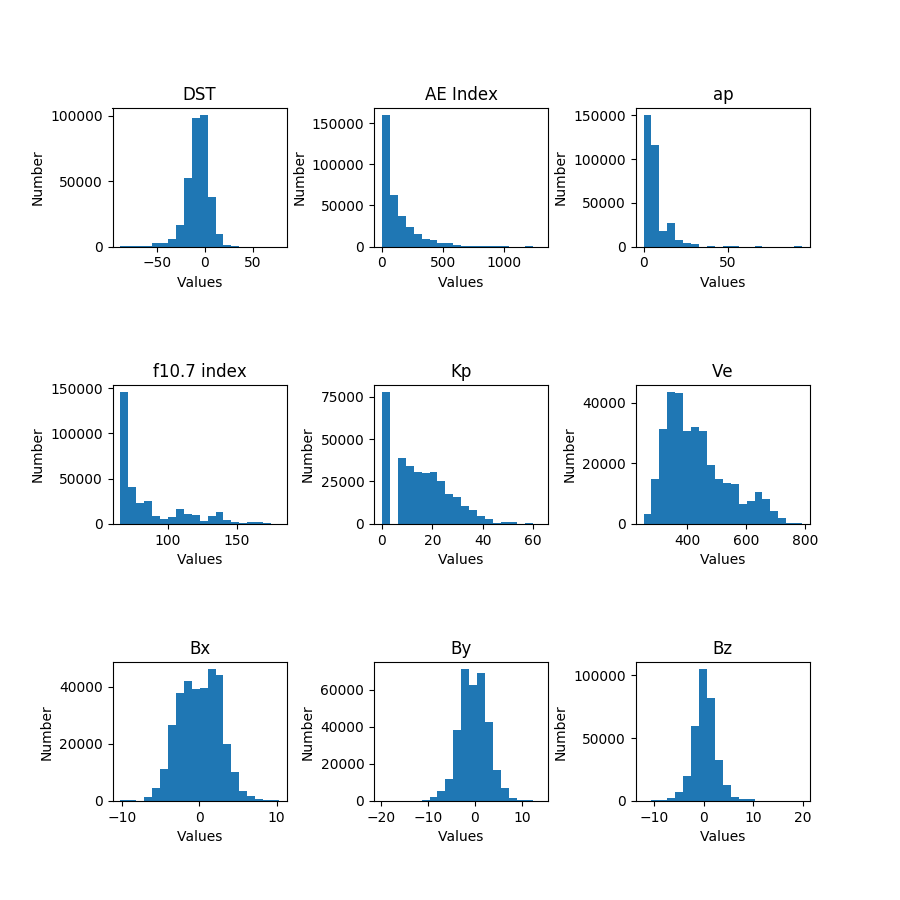

/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


In [2]:
%matplotlib notebook

vari_set = ['DST',
            'AE Index',
            'ap',
            'f10.7 index',
            'Kp',
            'Ve',
            'Bx',
            'By',
            'Bz']
iteration = range(-8,8)
MI = np.zeros([len(iteration), len(vari_set)])
MI_mean = np.zeros([len(iteration), len(vari_set)])
MI_std = np.zeros([len(iteration), len(vari_set)])
CMI = np.zeros([len(iteration), len(vari_set)])
CMI_mean = np.zeros([len(iteration), len(vari_set)])
CMI_std = np.zeros([len(iteration), len(vari_set)])

i = 0
data = sio.loadmat('data/Delay/33w_'+str(i)+'.mat') 

ALT = data['out'][:,0]
mLat = data['out'][:,1]
mLon = data['out'][:,2]
mLT = data['out'][:,3]
VTEC0 = data['out'][:,4]

varis = data['out'][:,5:14]
DoY = data['out'][:,14]
VTEC1 = data['out'][:,15]
NmF2 = data['out'][:,16]

fig1 = plt.figure(0, figsize=(9,9))

for i in range(len(vari_set)):

    plt.subplot(331+i)
    plt.hist(varis[:,i],20)
    plt.subplots_adjust(wspace =0.5, hspace =1)
    plt.xlabel('Values')
    plt.ylabel('Number')
    plt.title(vari_set[i])


plt.show()

In [4]:
%matplotlib notebook

vari_set = ['DST',
            'AE Index',
            'ap',
            'f10.7 index',
            'Kp',
            'Ve',
            'Bx',
            'By',
            'Bz']
iteration = range(-8,8,1)
MI = np.zeros([len(iteration), len(vari_set)])
MI_mean = np.zeros([len(iteration), len(vari_set)])
MI_std = np.zeros([len(iteration), len(vari_set)])
CMI = np.zeros([len(iteration), len(vari_set)])
CMI_mean = np.zeros([len(iteration), len(vari_set)])
CMI_std = np.zeros([len(iteration), len(vari_set)])

for i in iteration:
    data = sio.loadmat('data/Delay/all_'+str(i)+'.mat') 
   
    ALT = data['out'][:,0]
    mLat = data['out'][:,1]
    mLon = data['out'][:,2]
    mLT = data['out'][:,3]
    VTEC0 = data['out'][:,4]
    
    varis = data['out'][:,5:14]
    DoY = data['out'][:,14]
    VTEC1 = data['out'][:,15]
    NmF2 = data['out'][:,16]

    '''
    
    fig1 = plt.figure(0, figsize=(9,9))

    for i in range(len(vari_set)):

        plt.subplot(331+i)
        plt.hist(varis[:,i])
        plt.subplots_adjust(wspace =0.5, hspace =1)
        plt.xlabel('Values')
        plt.ylabel('Number')
        
    plt.show()
    '''
    #ipdb.set_trace()
    #print(i)
    ind = np.where(np.abs((mLat)>60) \
                   #& (mLat<-58+5)\
                   #& (mLon>20-10)\
                   #& (mLon<20+10)\
                   & (~np.isnan(varis[:,0])) \
                   & (~np.isnan(varis[:,1])) \
                   & (~np.isnan(varis[:,2])) \
                   & (~np.isnan(varis[:,3])) \
                   & (~np.isnan(varis[:,4])) \
                   & (~np.isnan(varis[:,5])) \
                   & (~np.isnan(varis[:,6])) \
                   & (VTEC1 > 0)\
                  )[0]
    sample_num = int(len(ind)*0.7)
    
    #ipdb.set_trace()

    #varis = varis[ind]/LA.norm(varis[ind])
    #VTEC0 = LA.norm(VTEC0[ind])
    
    varis = varis[ind,:]
    
    #ipdb.set_trace()
    varis = varis[:,:] - varis[:,:].min(axis=0)
    varis = varis/(varis[:,:].max(axis=0) - varis[:,:].min(axis=0))
    varis =np.round(varis*100)
    
    #print(varis)
    
    VTEC0 = VTEC0[ind]
    VTEC1 = VTEC1[ind]
    NmF2 = np.log(NmF2[ind])
    
    #ipdb.set_trace()
    NmF2 = NmF2[:] - NmF2[:].min(axis=0)
    NmF2 = NmF2/(NmF2[:].max(axis=0) - NmF2[:].min(axis=0))
    NmF2 =np.round(NmF2*100)
    
    #ipdb.
    for j in range(varis.shape[1]):
        print('j=',j)
        num_resample = 20
        MI_t = np.zeros(num_resample)
        CMI_t = np.zeros(num_resample)
        for k in range(num_resample):

            ind_t = np.array(range(ind.shape[0]))
            # shuffle the ind randomly 50 times, and each time with 60% data

            np.random.shuffle(ind_t)
            #ipdb.set_trace()
            ind_t = ind_t[0:sample_num]
            MI_t[k] = normalized_mutual_info_score(
                varis[ind_t,j],NmF2[ind_t])
            CMI_t[k] = drv.information_mutual_conditional(
                varis[ind_t,j],NmF2[ind_t],\
                varis[ind_t,3])
        #ipdb.set_trace()

        MI_mean[np.int((i+8)/1),j] = MI_t.mean()
        CMI_mean[np.int((i+8)/1),j] = CMI_t.mean()
        MI_std[np.int((i+8)/1),j] = MI_t.std()
        CMI_std[np.int((i+8)/1),j] = CMI_t.std()
        #ipdb.set_trace()

        MI[np.int((i+8)/1),j]=normalized_mutual_info_score(
            varis[0:sample_num,j],NmF2[0:sample_num])
                
        CMI[np.int((i+8)/1),j]=drv.information_mutual_conditional(
            varis[0:sample_num,j],NmF2[0:sample_num],\
            varis[0:sample_num,3])




j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8
j= 0
j= 1
j= 2
j= 3
j= 4
j= 5
j= 6
j= 7
j= 8


In [5]:
print(MI_std)
print(MI_t)

[[0.00282527 0.00362478 0.00306537 0.00249445 0.00323998 0.00232052
  0.00317399 0.00242001 0.00264996]
 [0.00329983 0.00276468 0.00255477 0.00332595 0.00217762 0.00305153
  0.00299968 0.00262566 0.00207674]
 [0.00344356 0.00260331 0.00271464 0.00282739 0.00343039 0.00301701
  0.0027799  0.00306321 0.00231001]
 [0.00368916 0.00285499 0.00233805 0.00372278 0.00250018 0.00271361
  0.00342012 0.00249768 0.00248892]
 [0.00351042 0.00301399 0.00325454 0.00366864 0.00324953 0.00257047
  0.00305187 0.00280387 0.00310971]
 [0.00233886 0.00247051 0.00199273 0.00294857 0.00289555 0.00243722
  0.00388403 0.00317067 0.0027671 ]
 [0.00327209 0.00285965 0.00286087 0.00317555 0.00373873 0.00253818
  0.00232279 0.00264269 0.00272183]
 [0.00261195 0.00301457 0.00234964 0.00316363 0.00270335 0.00295705
  0.00335742 0.00277449 0.00305311]
 [0.00037716 0.00047142 0.00058944 0.00062188 0.00054514 0.00072033
  0.00047713 0.00050331 0.00038024]
 [0.00034625 0.00042637 0.00041418 0.00111976 0.00044869 0.00056

<IPython.core.display.Javascript object>


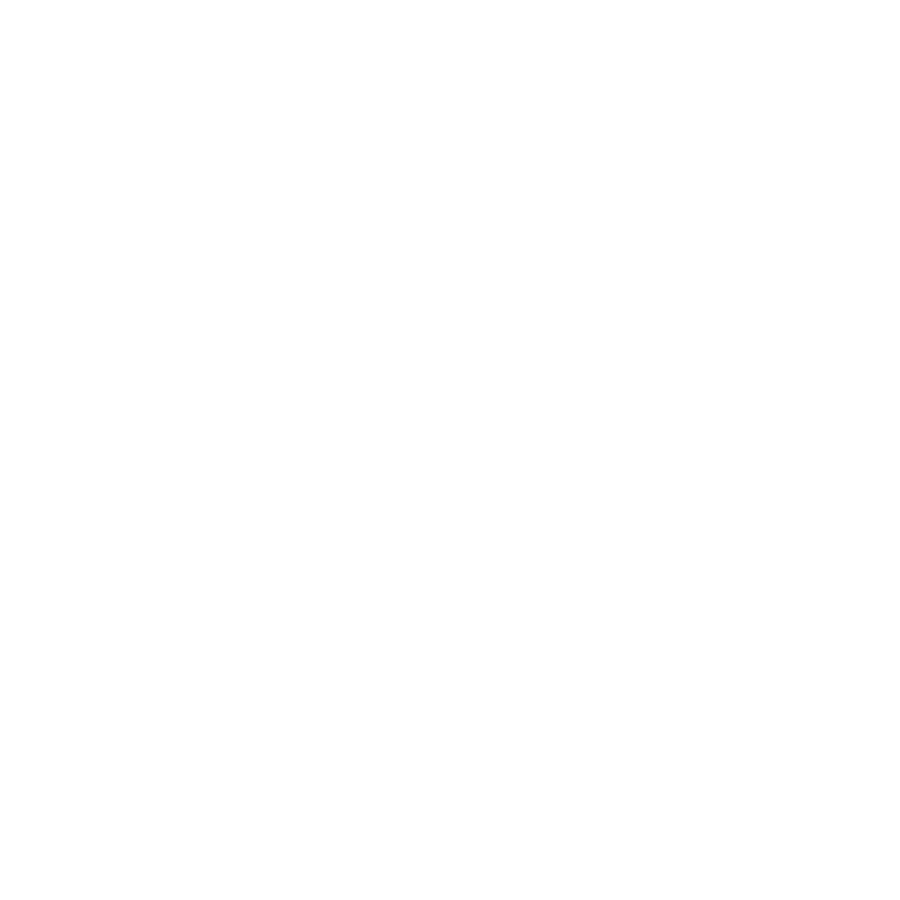

<IPython.core.display.Javascript object>


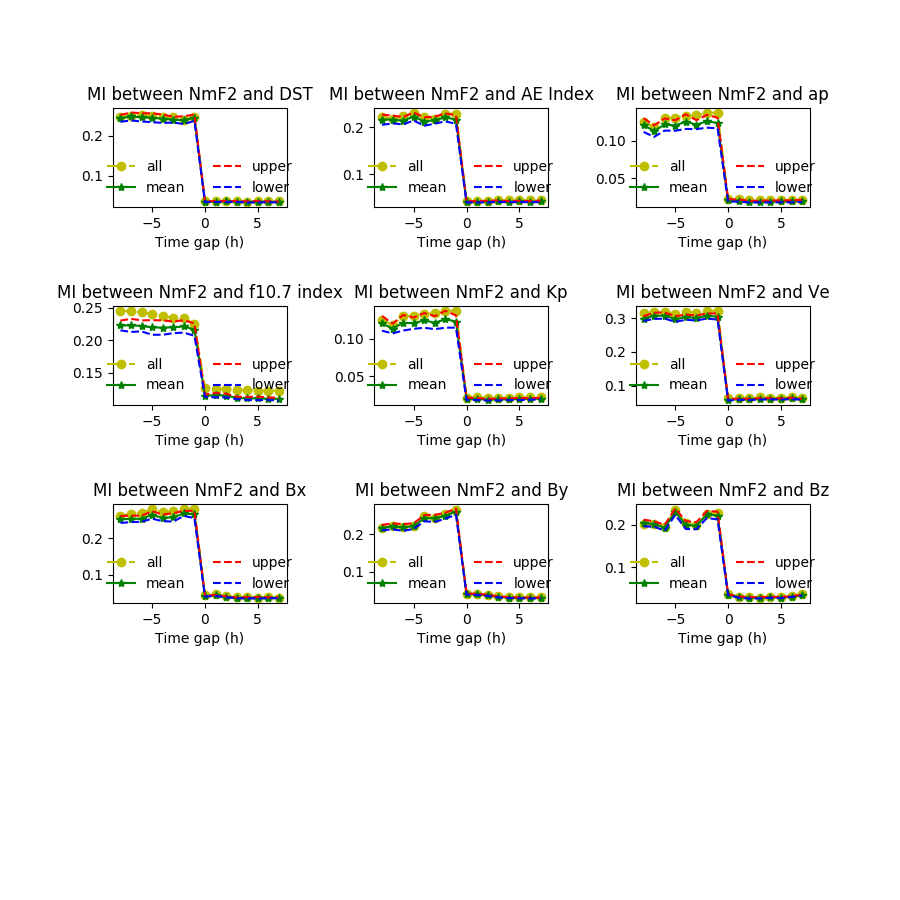

In [6]:



fig1 = plt.figure(0, figsize=(9,9))

for i in range(len(vari_set)):

    plt.subplot(431+i)
    plt.plot(iteration,CMI[:,i],'yo-.',label='all')
    plt.plot(iteration,CMI_mean[:,i],'g*-',label='mean')
    plt.plot(iteration,CMI_mean[:,i]+3*CMI_std[:,i],'r--',label='upper')
    plt.plot(iteration,CMI_mean[:,i]-3*CMI_std[:,i],'b--',label='lower')
    plt.subplots_adjust(wspace =0.5, hspace =1)
    plt.xlabel('Time gap (h)')
    plt.legend(frameon=False, loc='lower center',ncol=2)
    plt.title('CMI :NmF2 (no F10.7), '+vari_set[i])

plt.show()
titlefig = 'CMI_test_NmF2_Ve_lowlat.png'
#fig1.savefig(titlefig, dpi=300)
plt.close()

fig2 = plt.figure(1, figsize=(9,9))

for i in range(len(vari_set)):

    plt.subplot(431+i)
    plt.plot(iteration,MI[:,i],'yo-.',label='all')
    plt.plot(iteration,MI_mean[:,i],'g*-',label='mean')
    plt.plot(iteration,MI_mean[:,i]+3*MI_std[:,i],'r--',label='upper')
    plt.plot(iteration,MI_mean[:,i]-3*MI_std[:,i],'b--',label='lower')
    plt.subplots_adjust(wspace =0.5, hspace =1)
    plt.xlabel('Time gap (h)')
    plt.legend(frameon=False, loc='lower center',ncol=2)
    plt.title('MI between NmF2 and '+vari_set[i])

plt.show()
titlefig = 'MI_test_NmF2_Ve_lowlat.png'
#fig2.savefig(titlefig, dpi=300)

